In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.featuresREB import *
from MODELS.pipeline import *
from MODELS.xgboostModel import *

/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_columns', None)

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_25.csv')


train_df = pd.concat([s19,s20,s21,s22,s23])
val_df = s24
test_df = s25

print(f"Training data shape: {train_df.shape}")
print(f"Training date range: {train_df['GAME_DATE'].min()} to {train_df['GAME_DATE'].max()}")
print(f"Validation data shape: {val_df.shape}")
print(f"Validation date range: {val_df['GAME_DATE'].min()} to {val_df['GAME_DATE'].max()}")
print(f"Test data shape: {test_df.shape}")
print(f"Test date range: {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")
train_df

Training data shape: (123509, 952)
Training date range: 2018-10-16 to 2023-04-09
Validation data shape: (26401, 947)
Validation date range: 2023-10-24 to 2024-04-14
Test data shape: (26306, 947)
Test date range: 2024-10-22 to 2025-04-13


Unnamed: 0  Unnamed: 0.2      PLAYER_NAME  PLAYER_ID    MATCHUP  \
0               0          47.0         Alex Len     203458  ATL @ NYK   
1               1          49.0   Alex Poythress    1627816  ATL @ NYK   
2               2          48.0  DeAndre' Bembry    1627761  ATL @ NYK   
3               3          90.0     Jaylen Adams    1629121  ATL @ NYK   
4               4          87.0       Jeremy Lin     202391  ATL @ NYK   
...           ...           ...              ...        ...        ...   
25917       25917           NaN     Kobi Simmons    1628424  CHA @ CLE   
25918       25918           NaN    Mark Williams    1631109  CHA @ CLE   
25919       25919           NaN    Nick Richards    1630208  CHA @ CLE   
25920       25920           NaN   Svi Mykhailiuk    1629004  CHA @ CLE   
25921       25921           NaN     Theo Maledon    1630177  CHA @ CLE   

      TEAM_ABBREVIATION     TEAM_ID OPP_ABBREVIATION  HOME_GAME   GAME_ID  \
0                   ATL  1610612737              NYK          0  21800007   
1                   ATL  1610612737              NYK          0  21800007   
2                   ATL  1610612737              NYK          0  21800007   
3                   ATL  1610612737              NYK          0  21800007   
4                   ATL  1610612737              NYK          0  21800007   
...                 ...         ...              ...        ...       ...   
25917               CHA  1610612766              CLE          0  22201218   
25918               CHA  1610612766              CLE          0  22201218   
25919               CHA  1610612766              CLE          0  22201218   
25920               CHA  1610612766              CLE          0  22201218   
25921               CHA  1610612766              CLE          0  22201218   

        GAME_DATE WL  PTS  AST  REB  FGM  FGA  FG_PCT  FG3M  FG3A  FG3_PCT  \
0      2018-10-17  L    7    2    4    3    6   0.500     0     2    0.000   
1      2018-10-17  L    9    0    2    4    8   0.500     1     3    0.333   
2      2018-10-17  L    2    4    4    1    4   0.250     0     0      NaN   
3      2018-10-17  L    0    1    1    0    1   0.000     0     1    0.000   
4      2018-10-17  L    8    1    5    3    6   0.500     0     2    0.000   
...           ... ..  ...  ...  ...  ...  ...     ...   ...   ...      ...   
25917  2023-04-09  W    0    3    2    0    1   0.000     0     1    0.000   
25918  2023-04-09  W   22    0   10    9   10   0.900     0     0      NaN   
25919  2023-04-09  W   11    1    8    3    4   0.750     0     0      NaN   
25920  2023-04-09  W   16    6    7    6   18   0.333     2    10    0.200   
25921  2023-04-09  W   18    6    8    7   13   0.538     0     2    0.000   

       FTM  FTA  FT_PCT  OREB  DREB  STL  BLK  TOV  PLUS_MINUS  FANTASY_PTS  \
0        1    2   0.500     2     2    0    1    3         -14         14.8   
1        0    1   0.000     1     1    1    0    3         -21         11.4   
2        0    0     NaN     0     4    2    0    2         -12         16.8   
3        0    0     NaN     0     1    0    0    0           4          2.7   
4        2    2   1.000     0     5    1    0    2          -5         16.5   
...    ...  ...     ...   ...   ...  ...  ...  ...         ...          ...   
25917    0    0     NaN     1     1    0    0    0           0          6.9   
25918    4    6   0.667     1     9    1    2    2           3         41.0   
25919    5    5   1.000     2     6    1    3    3           8         31.1   
25920    2    2   1.000     4     3    2    0    3           5         36.4   
25921    4    4   1.000     1     7    1    0    3          17         36.6   

       POINT_PER_SHOT       EFG START_POSITION  COMMENT  OFF_RATING  \
0               1.017  0.500000              C      NaN        92.3   
1               1.066  0.562500            NaN      NaN        68.0   
2               0.500  0.250000            NaN      NaN        80.7   
3               0.000  

In [3]:
# newFeatures = val_df.columns[val_df.columns.tolist().index('STARTING'):].tolist()
# df_subset = val_df[newFeatures]
top_features =[
'RBC_ROLLING_AVG_7',
 'RBC_ROLLING_AVG_25',
 'RBC_ROLLING_AVG_10',
 'REB_WITHOUT_STAR',
 'TEAM_REB_ROLLING_AVG_5',
 'RBC_ROLLING_AVG_15',
 'RBC_ROLLING_AVG_5',
 'REB_ROLLING_AVG_7',
 'STARTING',
 'RBC_ROLLING_AVG_40',
 'RBC_AVG_TO_DATE',
 'REB_ROLLING_AVG_40',
 'DRBC_AVG_TO_DATE',
 'DRBC_ROLLING_AVG_25',
 'REB_PER_40_X_POSS',
 'MIN_AVG_TO_DATE',
 'REB_ROLLING_AVG_25',
 'REB_PER_MIN_X_POSS',
 'MIN_ROLLING_AVG_10',
 'REB_AVG_TO_DATE',
 'REB_ROLLING_AVG_15',
 'REB_PER_40_X_TEAM_OFF',
 'DRBC_ROLLING_AVG_15',
 'REB_PER_MIN_X_TEAM_OFF',
 'REB_ROLLING_AVG_10',
 'REB_PER_MIN_ROLLING_AVG_15',
 'MIN_ROLLING_AVG_5',
 'PLAYER_HOME_AVG_REB_TO_DATE',
 'MIN_LAG_1',
 'REB_ROLLING_AVG_5',
 'TEAM_REB_ROLLING_AVG_10',
 'REB_PER_MIN_ROLLING_AVG_40',
 'PLAYER_IS_TEAM_BEST_REBOUNDER',
 'DRBC_ROLLING_AVG_5',
 'REB_PER_MIN_X_OPP_DEF_RATING',
 'RBC_WITHOUT_STAR',
 'REB_PER_40_X_OPP_DEF_RATING',
 'FANTASY_PTS_LAG_1',
 'DRBC_WITHOUT_STAR',
 'REB_PER_MIN',
 'MATCHUP_AVG_REB_LAST_3_TO_DATE',
 'DREB_WITHOUT_STAR',
 'POSS_LAG_1',
 'PTS_PAINT_ROLLING_AVG_5',
 'RBC_LAG_1',
 'REB_PER_36_WITHOUT_STAR',
 'DREB_PCT_ROLLING_AVG_40',
 'MIN_VOLATILITY_10_TO_DATE',
 'DREB_PCT_ROLLING_AVG_10',
 'TEAM_STAR_OUT',
 'DREB_PCT_ROLLING_AVG_15',
 'DREB_PCT_WITHOUT_STAR',
 'REB_PCT_ROLLING_AVG_25',
 'REB_PCT_WITHOUT_STAR',
 'DREB_PCT_ROLLING_AVG_25',
 'REB_PER_36',
 'GUARD',
 'REB_PCT_AVG_TO_DATE',
 'DREB_PCT_AVG_TO_DATE',
 'REB_PCT_ROLLING_AVG_40',
 'CENTER']


In [ ]:
# from sklearn.inspection import permutation_importance

# def select_features_xgb_importance(
#     X,
#     y,
#     top_n=40,
#     n_runs=5,
#     include_context=True,
#     validate_permutation=False
# ):
#     feature_scores = np.zeros(X.shape[1])

#     # Run multiple XGBoost fits to stabilize importance
#     for seed in range(n_runs):
#         xgb = XGBRegressor(
#             n_estimators=300,
#             learning_rate=0.05,
#             max_depth=6,
#             subsample=0.8,
#             colsample_bytree=0.8,
#             random_state=42 + seed,
#             verbosity=0
#         )
#         xgb.fit(X, y)
#         feature_scores += xgb.feature_importances_

#     importance_df = pd.DataFrame({
#         'feature': X.columns,
#         'importance': feature_scores / n_runs
#     }).sort_values('importance', ascending=False)

#     top_features = importance_df.head(top_n)['feature'].tolist()

#     # Add context features that improve stability and interpretability
#     if include_context:
#         context_features = [
#             'MIN_ROLLING_AVG_5', 'MIN_ROLLING_AVG_10', 'MIN_LAG_1','MIN_AVG_TO_DATE', 'MIN_VOLATILITY_10_TO_DATE'
#         ]
#         for f in context_features:
#             if f in X.columns and f not in top_features:
#                 top_features.append(f)

#     # Optional: Permutation importance validation
#     if validate_permutation:
#         print("Validating with permutation importance...")
#         model = XGBRegressor(n_estimators=300, random_state=42, verbosity=0)
#         model.fit(X[top_features], y)
#         perm = permutation_importance(model, X[top_features], y, n_repeats=5, random_state=42)
#         perm_df = pd.DataFrame({
#             'feature': top_features,
#             'perm_importance': perm.importances_mean
#         }).sort_values('perm_importance', ascending=False)

#         # Filter out weak features
#         perm_df = perm_df[perm_df['perm_importance'] > 0]
#         top_features = perm_df['feature'].tolist()

#     print(f"Selected {len(top_features)} total features")
#     print("Top 10 most important:")
#     for i, f in enumerate(top_features[:10]):
#         print(f"{i+1}. {f}")

#     return X[top_features], top_features

# selected_features, top_features = select_features_xgb_importance(
#     train_df[newFeatures],
#     train_df['REB'],
#     top_n=60,                 # increase if you want more coverage
#     n_runs=5,                 # stabilizes importance ranking
#     include_context=True,     # adds game context
#     validate_permutation=True # prunes noise
# )

Validating with permutation importance...
Selected 64 total features
Top 10 most important:
1. RBC_ROLLING_AVG_7
2. RBC_ROLLING_AVG_25
3. RBC_ROLLING_AVG_10
4. REB_WITHOUT_STAR
5. TEAM_REB_ROLLING_AVG_5
6. RBC_ROLLING_AVG_15
7. RBC_ROLLING_AVG_5
8. REB_ROLLING_AVG_7
9. REB_PER_40
10. STARTING


In [4]:
xgbModel, val_metrics, used_cats = fit_train_val(
    train_df, val_df,
    features=top_features,
    target_col="REB",
    date_col="GAME_DATE",
    player_col="PLAYER_ID",
    use_gpu=False,
    tune_hyperparams=False,
    tune_iters=100
)

print("Validation metrics:", val_metrics)

test_metrics, residuals_df = evaluate_test(xgbModel, test_df, top_features, "REB", used_cats)
print("Test metrics:", test_metrics)


Validation metrics: {'RMSE': 2.3497236876299437, 'MAE': 1.780738690636821, 'R2': 0.541356086730957, 'best_iteration': 645}
Test metrics: {'RMSE': 2.3846470514708216, 'MAE': 1.8148774450236578, 'R2': 0.5269068479537964}


In [5]:
joblib.dump(xgbModel, 'Models/xgbREBModelNoOppStats.pkl')
joblib.dump(top_features, 'Models/topREBfeaturesNoOppStats.pkl')

['Models/topREBfeaturesNoOppStats.pkl']

In [6]:
feature_importance = pd.DataFrame({
    'feature': top_features,
    'importance': xgbModel.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 25 vs Bottom 25 Features - Side by Side")
print("=" * 100)

# Get top 25 and bottom 25
top25 = feature_importance.head(25).reset_index(drop=True)
bottom25 = feature_importance.tail(25).reset_index(drop=True)

# Reset index for bottom 25 to start from 0
bottom25 = bottom25.reset_index(drop=True)

# Create side-by-side comparison
comparison = pd.concat([
    top25.rename(columns={'feature': 'TOP_FEATURES', 'importance': 'TOP_IMPORTANCE'}),
    bottom25.rename(columns={'feature': 'BOTTOM_FEATURES', 'importance': 'BOTTOM_IMPORTANCE'})
], axis=1)

print(comparison.to_string(index=False))

Top 25 vs Bottom 25 Features - Side by Side
                 TOP_FEATURES  TOP_IMPORTANCE                BOTTOM_FEATURES  BOTTOM_IMPORTANCE
           REB_ROLLING_AVG_15        0.308207                      MIN_LAG_1           0.003684
           REB_ROLLING_AVG_40        0.103787              REB_ROLLING_AVG_5           0.003683
           REB_ROLLING_AVG_10        0.072877            REB_PCT_AVG_TO_DATE           0.003676
                     STARTING        0.064684           DREB_PCT_AVG_TO_DATE           0.003609
           REB_ROLLING_AVG_25        0.063997             RBC_ROLLING_AVG_25           0.003567
           RBC_ROLLING_AVG_10        0.040734                     POSS_LAG_1           0.003418
              REB_AVG_TO_DATE        0.033520     REB_PER_MIN_ROLLING_AVG_15           0.003133
           RBC_ROLLING_AVG_15        0.023316 MATCHUP_AVG_REB_LAST_3_TO_DATE           0.003130
            RBC_ROLLING_AVG_7        0.022743            DRBC_ROLLING_AVG_15           0.002

In [7]:
res = residuals_df.sort_values(by='residual', ascending=False, inplace=True)
top25errors = residuals_df.head(30).reset_index(drop=True)
top25errors

,actual,predicted,residual,PLAYER_NAME,MATCHUP,TEAM_PTS,OPP_PTS,STARTING,MIN
0,0,13.393678,13.393678,Domantas Sabonis,SAC @ HOU,113,103.0,1,1.27
1,2,14.651969,12.651969,Alperen Sengun,HOU vs. OKC,125,111.0,1,33.83
2,0,12.256103,12.256103,Jarrett Allen,CLE vs. IND,118,126.0,1,0.68
3,5,15.526195,10.526195,Alperen Sengun,HOU @ SAS,106,109.0,1,22.05
4,2,12.498819,10.498819,Anthony Davis,LAL @ PHI,104,118.0,1,9.83
5,4,14.238846,10.238846,Alperen Sengun,HOU vs. PHX,111,104.0,1,33.02
6,1,11.113600,10.113600,Domantas Sabonis,SAC vs. MEM,132,122.0,1,12.07
7,1,10.796635,9.796635,Jalen Duren,DET @ MIL,133,140.0,1,8.35
8,0,9.575862,9.575862,Jalen Duren,DET vs. PHI,96,111.0,1,12.53
9,2,11.443770,9.443770,Isaiah Hartenstein,OKC @ BKN,129,121.0,1,23.82


C:\Users\alexg\AppData\Local\Temp\ipykernel_27020\2114919491.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
C:\Users\alexg\AppData\Local\Temp\ipykernel_27020\2114919491.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])


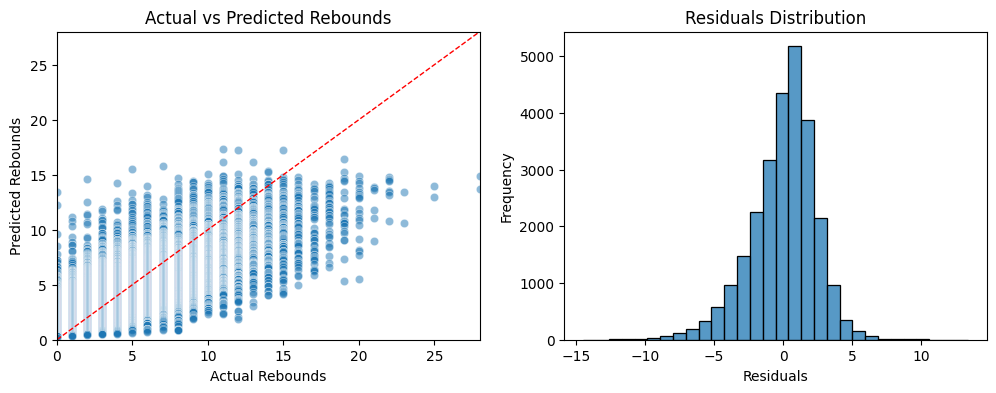

In [8]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))

sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
minVal = min(residuals_df['actual'].min(), residuals_df['predicted'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['predicted'].max())
axes[0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0].set_xlim(minVal, maxVal)
axes[0].set_ylim(minVal, maxVal)
axes[0].set_title('Actual vs Predicted Rebounds')
axes[0].set_xlabel('Actual Rebounds')
axes[0].set_ylabel('Predicted Rebounds')

sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

plt.show()